In [ ]:
import pandas as pd

# Create sample dataset
data = {
    'Id': [1, 2, 3, 4, 5],
    'Text': [
        'The product quality is excellent and delivery was on time.',
        'Very disappointing experience. The item stopped working in two days.',
        'Average product, not too good and not too bad.',
        'I absolutely love this! Works perfectly and worth the price.',
        'The packaging was poor and the product didn’t match the description.'
    ],
    'Score': [5, 1, 3, 5, 2]
}

# Convert to DataFrame
df_sample = pd.DataFrame(data)

# Save as CSV
df_sample.to_csv('Reviews_sample.csv', index=False)

# Display the dataset
print(df_sample)


   Id                                               Text  Score
0   1  The product quality is excellent and delivery ...      5
1   2  Very disappointing experience. The item stoppe...      1
2   3     Average product, not too good and not too bad.      3
3   4  I absolutely love this! Works perfectly and wo...      5
4   5  The packaging was poor and the product didn’t ...      2


In [ ]:
df = pd.read_csv('Reviews_sample.csv')
print(df)


   Id                                               Text  Score
0   1  The product quality is excellent and delivery ...      5
1   2  Very disappointing experience. The item stoppe...      1
2   3     Average product, not too good and not too bad.      3
3   4  I absolutely love this! Works perfectly and wo...      5
4   5  The packaging was poor and the product didn’t ...      2


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Dataset loaded successfully!

   Id                                               Text  Score
0   1  The product quality is excellent and delivery ...      5
1   2  Very disappointing experience. The item stoppe...      1
2   3     Average product, not too good and not too bad.      3
3   4  I absolutely love this! Works perfectly and wo...      5
4   5  The packaging was poor and the product didn’t ...      2

VADER Sentiment Scores:
   Id                                               Text    pos    neu    neg  \
0   1  The product quality is excellent and delivery ...  0.291  0.709  0.000   
1   2  Very disappointing experience. The item stoppe...  0.000  0.597  0.403   
2   3     Average product, not too good and not too bad.  0.233  0.571  0.196   
3   4  I absolutely love this! Works perfectly and wo...  0.645  0.355  0.000   
4   5  The packaging was poor and the product didn’t ...  0.000  0.763  0.237   

   compound  
0    0.5719  
1   -0.6590  
2    0.1139  
3    0.8976  
4   

/tmp/ipython-input-3193508695.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='compound', data=df, palette='coolwarm')


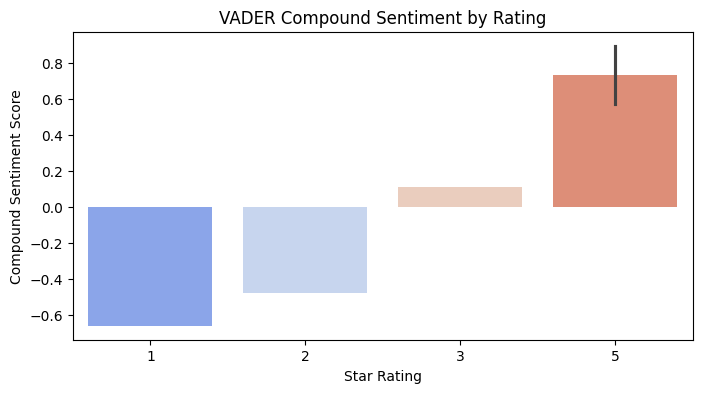

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

 20%|██        | 1/5 [00:00<00:01,  3.39it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

100%|██████████| 5/5 [00:00<00:00,  6.23it/s]



RoBERTa Sentiment Scores:
   Id  roberta_neg  roberta_neu  roberta_pos
0   1     0.002863     0.024106     0.973031
1   2     0.975104     0.022457     0.002439
2   3     0.222457     0.502373     0.275170
3   4     0.002121     0.006325     0.991554
4   5     0.938293     0.056404     0.005303


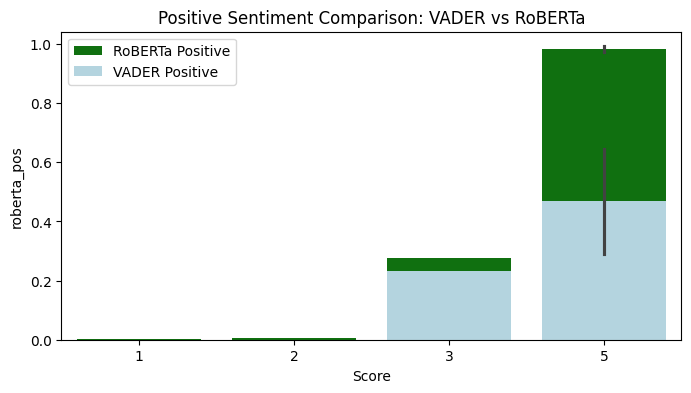


Final Combined Sentiment Data:
   Id                                               Text  Score  compound  \
0   1  The product quality is excellent and delivery ...      5    0.5719   
1   2  Very disappointing experience. The item stoppe...      1   -0.6590   
2   3     Average product, not too good and not too bad.      3    0.1139   
3   4  I absolutely love this! Works perfectly and wo...      5    0.8976   
4   5  The packaging was poor and the product didn’t ...      2   -0.4767   

   roberta_pos  roberta_neu  roberta_neg  
0     0.973031     0.024106     0.002863  
1     0.002439     0.022457     0.975104  
2     0.275170     0.502373     0.222457  
3     0.991554     0.006325     0.002121  
4     0.005303     0.056404     0.938293  


In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from scipy.special import softmax
from tqdm import tqdm
import nltk

# Download NLTK resources
nltk.download('vader_lexicon')
nltk.download('punkt')

# -----------------------------------------------------------
# Step 1: Load Sample Dataset
# -----------------------------------------------------------
# Use the existing df_sample variable instead of reading from CSV
df = df_sample
print("Dataset loaded successfully!\n")
print(df)

# -----------------------------------------------------------
# Step 2: VADER Sentiment Analysis
# -----------------------------------------------------------
sia = SentimentIntensityAnalyzer()

vader_results = []
for review in df['Text']:
    vader_results.append(sia.polarity_scores(review))

vader_df = pd.DataFrame(vader_results)
df = pd.concat([df, vader_df], axis=1)

print("\nVADER Sentiment Scores:")
print(df[['Id', 'Text', 'pos', 'neu', 'neg', 'compound']])

# -----------------------------------------------------------
# Step 3: Visualization - Compound Score by Rating
# -----------------------------------------------------------
plt.figure(figsize=(8, 4))
sns.barplot(x='Score', y='compound', data=df, palette='coolwarm')
plt.title('VADER Compound Sentiment by Rating')
plt.xlabel('Star Rating')
plt.ylabel('Compound Sentiment Score')
plt.show()

# -----------------------------------------------------------
# Step 4: RoBERTa Sentiment Analysis (Pretrained Model)
# -----------------------------------------------------------
MODEL = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

def polarity_scores_roberta(text):
    encoded_text = tokenizer(text, return_tensors='pt')
    output = model(**encoded_text)
    scores = softmax(output[0][0].detach().numpy())
    return {
        'roberta_neg': scores[0],
        'roberta_neu': scores[1],
        'roberta_pos': scores[2]
    }

roberta_results = []
for review in tqdm(df['Text']):
    roberta_results.append(polarity_scores_roberta(review))

roberta_df = pd.DataFrame(roberta_results)
df = pd.concat([df, roberta_df], axis=1)

print("\nRoBERTa Sentiment Scores:")
print(df[['Id', 'roberta_neg', 'roberta_neu', 'roberta_pos']])

# -----------------------------------------------------------
# Step 5: Combined Sentiment Comparison
# -----------------------------------------------------------
plt.figure(figsize=(8, 4))
sns.barplot(x='Score', y='roberta_pos', data=df, color='green', label='RoBERTa Positive')
sns.barplot(x='Score', y='pos', data=df, color='lightblue', label='VADER Positive')
plt.title('Positive Sentiment Comparison: VADER vs RoBERTa')
plt.legend()
plt.show()

# -----------------------------------------------------------
# Step 6: Final Output
# -----------------------------------------------------------
print("\nFinal Combined Sentiment Data:")
print(df[['Id', 'Text', 'Score', 'compound', 'roberta_pos', 'roberta_neu', 'roberta_neg']])